Training Model

In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv("C:/Users/RAVI/Downloads/Data Scientist Tests/Data Scientist Tests/Use Case 2/train.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            491 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            488 non-null    object 
 3   Dependents         478 non-null    object 
 4   Education          491 non-null    object 
 5   Self_Employed      463 non-null    object 
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         474 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     447 non-null    float64
 11  Property_Area      491 non-null    object 
 12  Loan_Status        491 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 50.0+ KB


In [4]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002051,Male,Yes,0,Graduate,No,2400,2167.0,115.0,360.0,1.0,Semiurban,Y
1,LP002255,Male,No,3+,Graduate,No,9167,0.0,185.0,360.0,1.0,Rural,Y
2,LP002877,Male,Yes,1,Graduate,No,1782,2232.0,107.0,360.0,1.0,Rural,Y
3,LP002931,Male,Yes,2,Graduate,Yes,6000,0.0,205.0,240.0,1.0,Semiurban,N
4,LP002743,Female,No,0,Graduate,No,2138,0.0,99.0,360.0,0.0,Semiurban,N


In [5]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,491.000000,491.000000,474.000000,480.000000,447.000000
mean,5450.040733,1672.187210,146.689873,341.950000,0.850112
std,6383.021473,3157.016665,82.914809,65.909389,0.357362
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2891.500000,0.000000,100.000000,360.000000,1.000000
50%,3813.000000,1213.000000,128.000000,360.000000,1.000000
75%,5929.000000,2253.500000,169.500000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [6]:
data['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.688391
N    0.311609
Name: proportion, dtype: float64

In [7]:
data.isnull().sum()

Loan_ID               0
Gender               11
Married               3
Dependents           13
Education             0
Self_Employed        28
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           17
Loan_Amount_Term     11
Credit_History       44
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
categorical_col=['Gender','Married','Education', 'Self_Employed', 'Property Area']

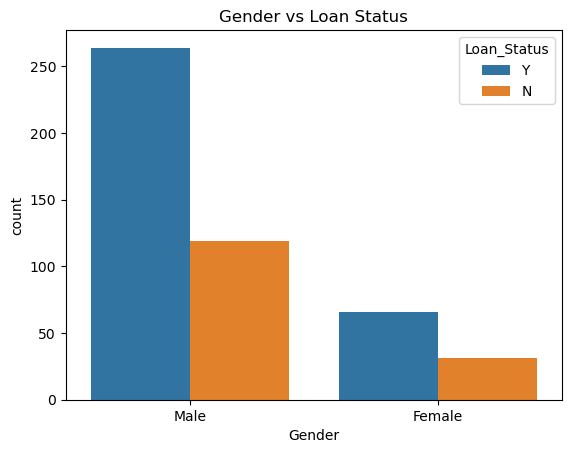

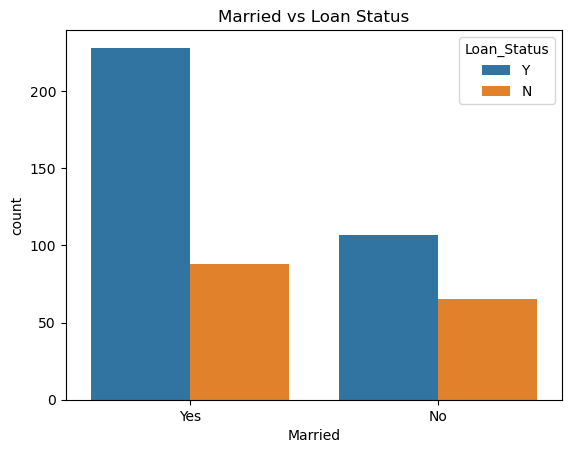

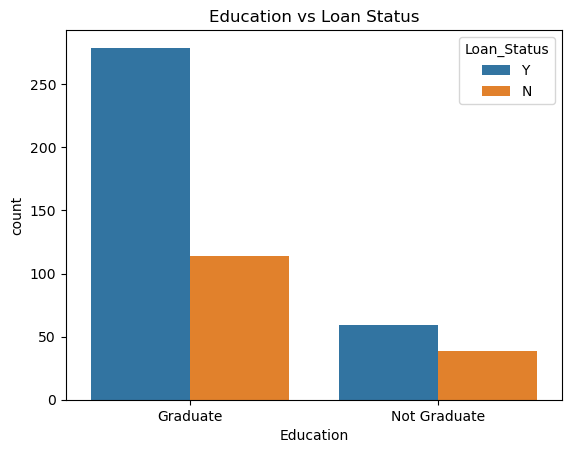

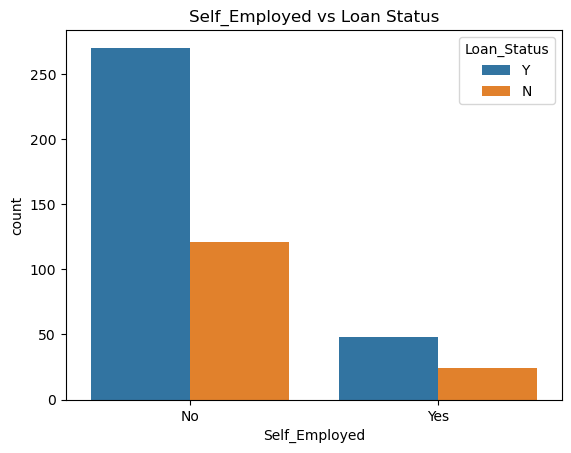

ValueError: Could not interpret input 'Property Area'

In [10]:
for col in categorical_col:
    sns.countplot(x=col, hue='Loan_Status', data=data)
    plt.title(f'{col} vs Loan Status')
    plt.show()

In [11]:
numerical_features=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']

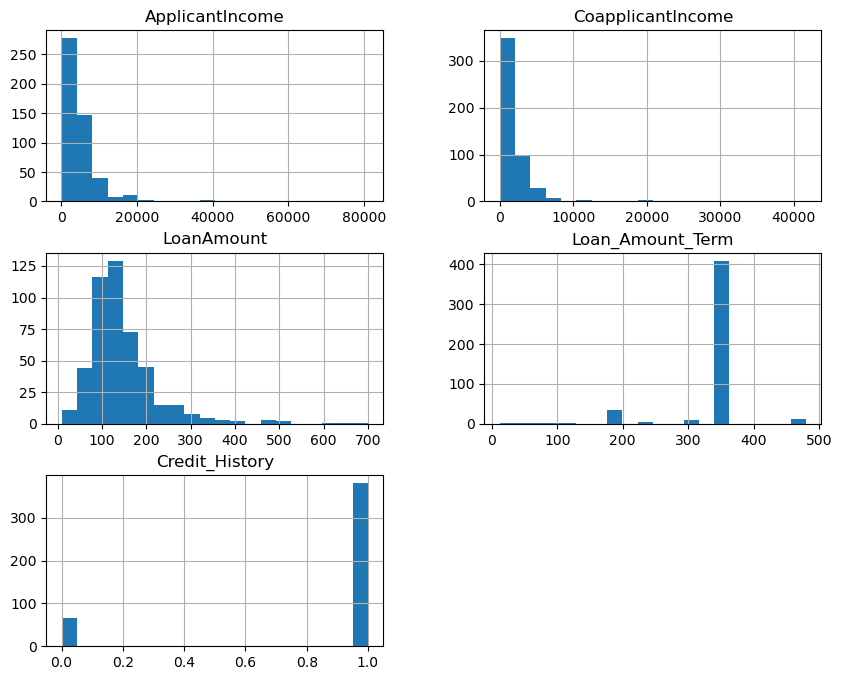

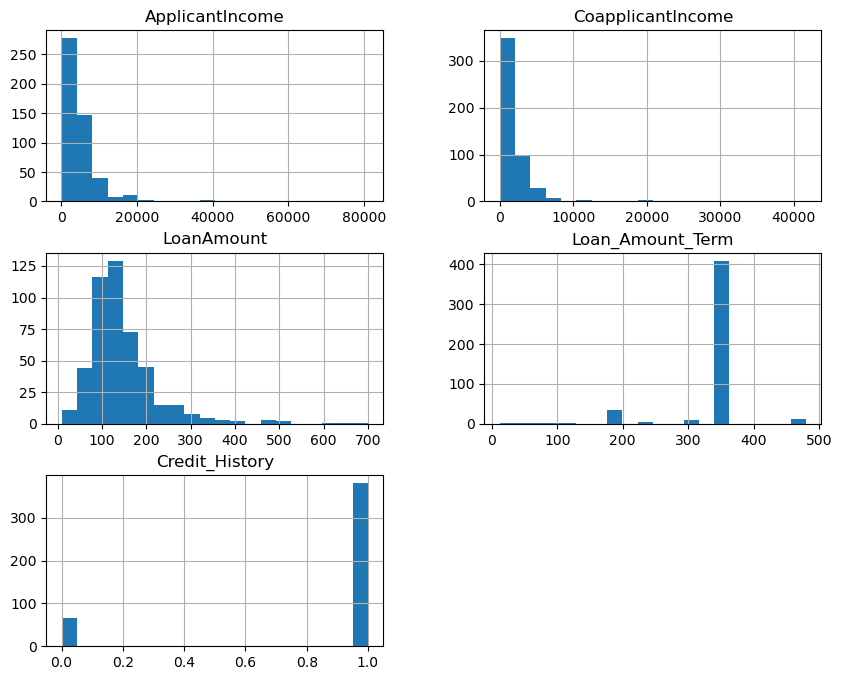

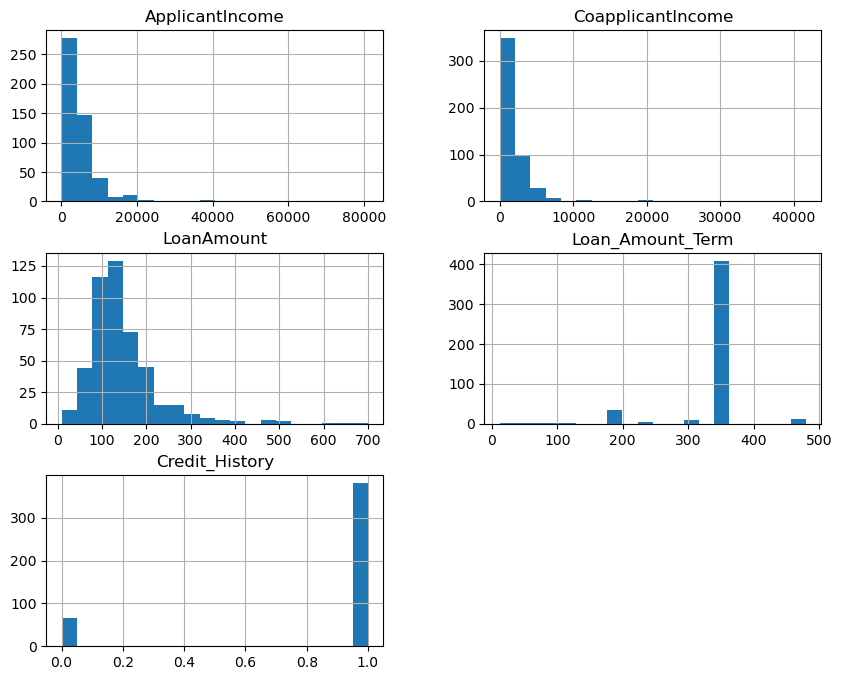

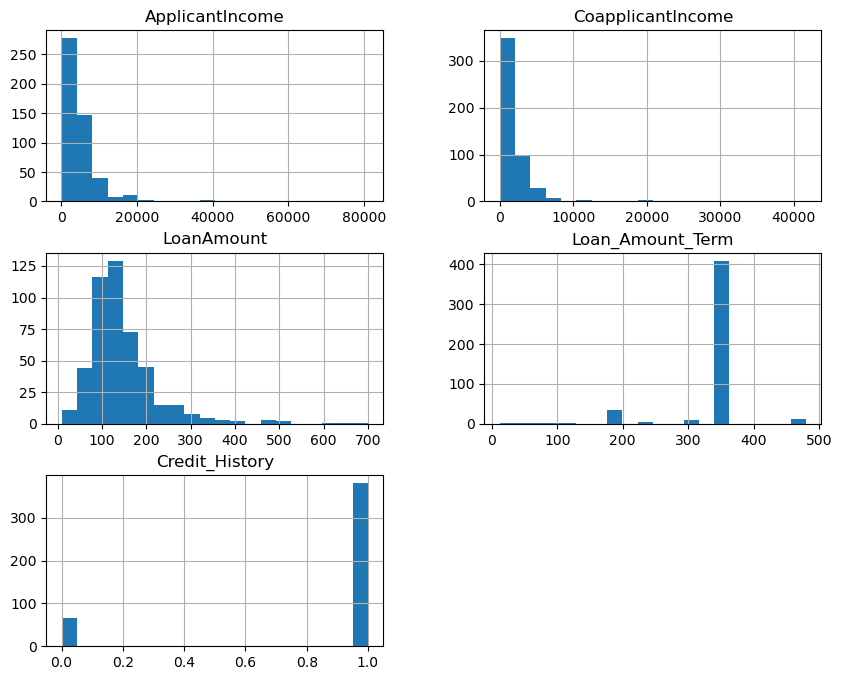

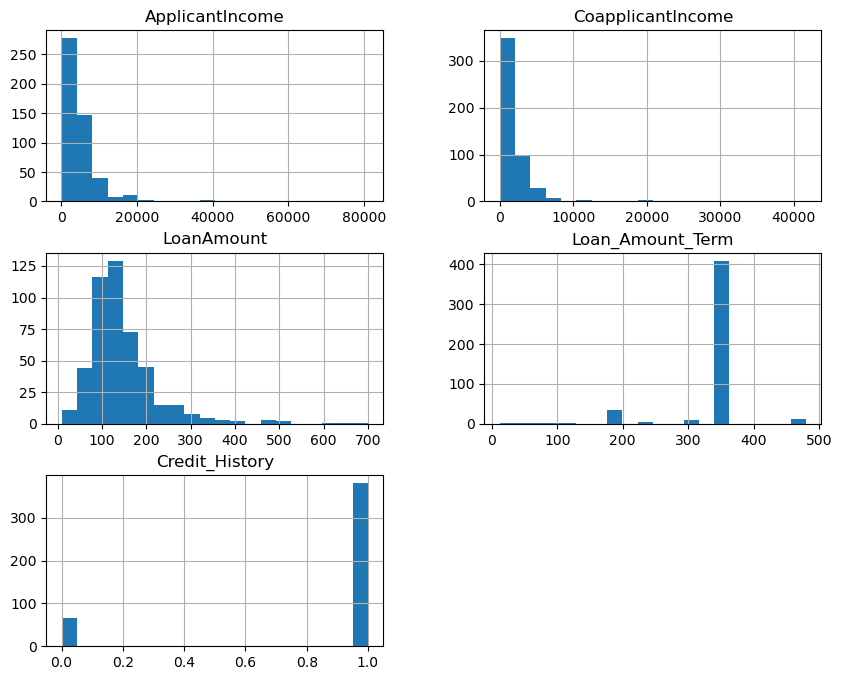

In [12]:
for col in numerical_features:
    data[numerical_features].hist(bins=20, figsize=(10,8))
    plt.show()

In [13]:
# Fill categorical with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [14]:
# Fill numerical with median
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median(), inplace=True)

In [15]:
data.Education.value_counts()

Education
Graduate        393
Not Graduate     98
Name: count, dtype: int64

In [16]:
# Convert target to binary
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 2})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 2})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 2})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 2})
data['Property_Area']= data['Property_Area'].map({'Urban':1, 'Semiurban':2, 'Rural':3})





# One-hot encoding
#data = pd.get_dummies(data, drop_first=True)

In [17]:
data['Dependents'] = data['Dependents'].replace('3+', 3).astype(float)


In [18]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002051,1,1,0.0,1,2,2400,2167.0,115.0,360.0,1.0,2,1
1,LP002255,1,2,3.0,1,2,9167,0.0,185.0,360.0,1.0,3,1
2,LP002877,1,1,1.0,1,2,1782,2232.0,107.0,360.0,1.0,3,1
3,LP002931,1,1,2.0,1,1,6000,0.0,205.0,240.0,1.0,2,0
4,LP002743,2,2,0.0,1,2,2138,0.0,99.0,360.0,0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP002888,1,2,0.0,1,2,3182,2917.0,161.0,360.0,1.0,1,1
487,LP002615,1,1,2.0,1,2,4865,5624.0,208.0,360.0,1.0,2,1
488,LP002738,1,2,2.0,1,2,3617,0.0,107.0,360.0,1.0,2,1
489,LP001666,1,2,0.0,1,2,8333,3750.0,187.0,360.0,1.0,3,1


In [19]:
data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data['LoanAmount_log'] = np.log(data['LoanAmount'] + 1)
data['TotalIncome_log'] = np.log(data['TotalIncome'] + 1)


In [20]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_log,TotalIncome_log
0,LP002051,1,1,0.0,1,2,2400,2167.0,115.0,360.0,1.0,2,1,4567.0,4.753590,8.426831
1,LP002255,1,2,3.0,1,2,9167,0.0,185.0,360.0,1.0,3,1,9167.0,5.225747,9.123474
2,LP002877,1,1,1.0,1,2,1782,2232.0,107.0,360.0,1.0,3,1,4014.0,4.682131,8.297793
3,LP002931,1,1,2.0,1,1,6000,0.0,205.0,240.0,1.0,2,0,6000.0,5.327876,8.699681
4,LP002743,2,2,0.0,1,2,2138,0.0,99.0,360.0,0.0,2,0,2138.0,4.605170,7.668094


In [21]:
from sklearn.model_selection import train_test_split

X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanAmount_log,TotalIncome_log
0,LP002051,1,1,0.0,1,2,2400,2167.0,115.0,360.0,1.0,2,1,4567.0,4.753590,8.426831
1,LP002255,1,2,3.0,1,2,9167,0.0,185.0,360.0,1.0,3,1,9167.0,5.225747,9.123474
2,LP002877,1,1,1.0,1,2,1782,2232.0,107.0,360.0,1.0,3,1,4014.0,4.682131,8.297793
3,LP002931,1,1,2.0,1,1,6000,0.0,205.0,240.0,1.0,2,0,6000.0,5.327876,8.699681
4,LP002743,2,2,0.0,1,2,2138,0.0,99.0,360.0,0.0,2,0,2138.0,4.605170,7.668094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP002888,1,2,0.0,1,2,3182,2917.0,161.0,360.0,1.0,1,1,6099.0,5.087596,8.716044
487,LP002615,1,1,2.0,1,2,4865,5624.0,208.0,360.0,1.0,2,1,10489.0,5.342334,9.258178
488,LP002738,1,2,2.0,1,2,3617,0.0,107.0,360.0,1.0,2,1,3617.0,4.682131,8.193677
489,LP001666,1,2,0.0,1,2,8333,3750.0,187.0,360.0,1.0,3,1,12083.0,5.236442,9.399638


In [23]:
data.Education.value_counts()

Education
1    393
2     98
Name: count, dtype: int64

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))


C:\Users\RAVI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7980
              precision    recall  f1-score   support

           0       0.87      0.42      0.57        31
           1       0.79      0.97      0.87        68

    accuracy                           0.80        99
   macro avg       0.83      0.69      0.72        99
weighted avg       0.81      0.80      0.77        99

Random Forest Accuracy: 0.7677
              precision    recall  f1-score   support

           0       0.68      0.48      0.57        31
           1       0.79      0.90      0.84        68

    accuracy                           0.77        99
   macro avg       0.74      0.69      0.70        99
weighted avg       0.76      0.77      0.76        99

SVM Accuracy: 0.6768
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.68      0.99      0.81        68

    accuracy                           0.68        99
   macro avg       0.34      0.49      

Validation Model

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")


Best parameters: {'max_depth': 3, 'n_estimators': 100}


In [26]:
import joblib

final_model = grid.best_estimator_
joblib.dump(final_model, 'loan_prediction_model.pkl')


['loan_prediction_model.pkl']

In [27]:
val_df=pd.read_csv("C:/Users/RAVI/Downloads/Data Scientist Tests/Data Scientist Tests/Use Case 2/validation.csv")

In [28]:

# Fill missing values
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    val_df[col].fillna(val_df[col].mode()[0], inplace=True)
val_df['LoanAmount'].fillna(val_df['LoanAmount'].median(), inplace=True)
val_df['Loan_Amount_Term'].fillna(val_df['Loan_Amount_Term'].median(), inplace=True)

# Create new features
val_df['TotalIncome'] = val_df['ApplicantIncome'] + val_df['CoapplicantIncome']
val_df['LoanAmount_log'] = np.log(val_df['LoanAmount'] + 1)
val_df['TotalIncome_log'] = np.log(val_df['TotalIncome'] + 1)

# Encode categoricals
val_df_encoded = pd.get_dummies(val_df, drop_first=True)

# Align with training columns
X_val = val_df_encoded.reindex(columns=X.columns, fill_value=0)


In [29]:
import joblib

# Load model
model = joblib.load('loan_prediction_model.pkl')

# Predict
val_preds = model.predict(X_val)


In [31]:
output = pd.DataFrame({
    'Loan_ID': val_df['Loan_ID'],
    'Predicted_Loan_Status': ['Y' if p == 1 else 'N' for p in val_preds]
})
print(output.head())



    Loan_ID Predicted_Loan_Status
0  LP001736                     N
1  LP001384                     Y
2  LP002841                     N
3  LP002097                     Y
4  LP002314                     Y
